In [1]:
import os
import gc
import copy
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

# -----------------------

In [2]:
candidates = [
    "/kaggle/input/ieee-cis-fraud-detection",
    "/kaggle/input/ieee-fraud-detection",
    "/kaggle/input/competitions/ieee-cis-fraud-detection",
    "/kaggle/input/competitions/ieee-fraud-detection",
]
PATH = next((p for p in candidates if os.path.exists(p)), None)
if PATH is None:
    raise FileNotFoundError(
        "No IEEE fraud dataset found under /kaggle/input. "
        "Add the IEEE-CIS Fraud Detection competition data as this notebook's input."
    )
print("Using PATH:", PATH, "->", os.listdir(PATH))



def reduce_mem_usage(df: pd.DataFrame) -> pd.DataFrame:
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtype
        if pd.api.types.is_float_dtype(col_type):
            df[col] = pd.to_numeric(df[col], downcast="float")
        elif pd.api.types.is_integer_dtype(col_type):
            df[col] = pd.to_numeric(df[col], downcast="integer")
    end_mem = df.memory_usage().sum() / 1024**2
    print(f"Memory: {start_mem:.1f} MB -> {end_mem:.1f} MB")
    return df

Using PATH: /kaggle/input/competitions/ieee-fraud-detection -> ['sample_submission.csv', 'test_identity.csv', 'train_identity.csv', 'test_transaction.csv', 'train_transaction.csv']


Memory: 1955.4 MB -> 1044.7 MB
OK — Rows, Cols: (590540, 434)
float32    399
object      31
int32        2
int8         1
int16        1
Name: count, dtype: int64
Fraud rate: 0.03499000914417313


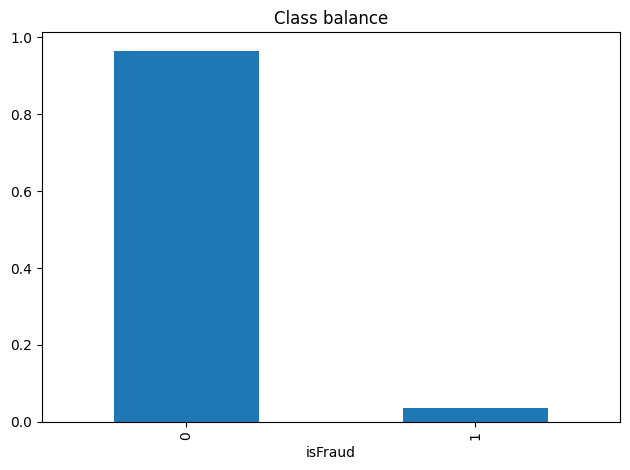

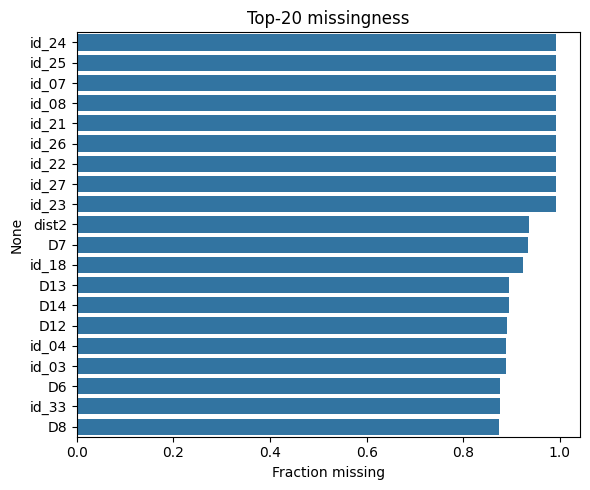

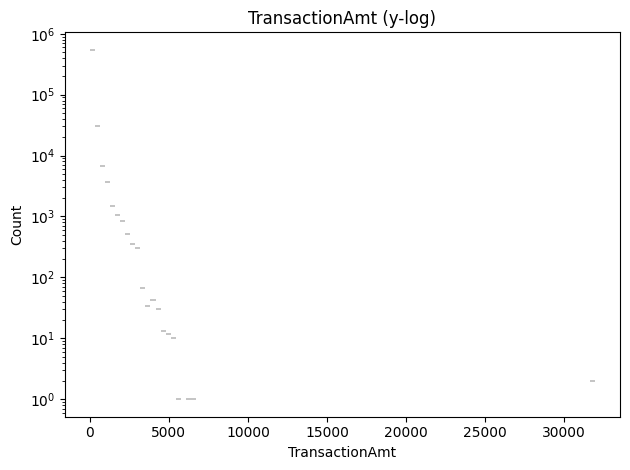

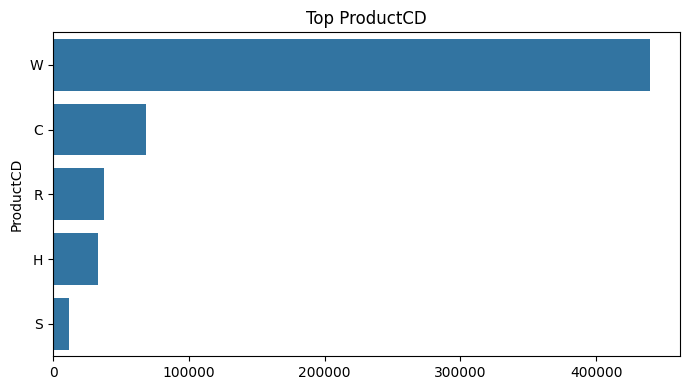

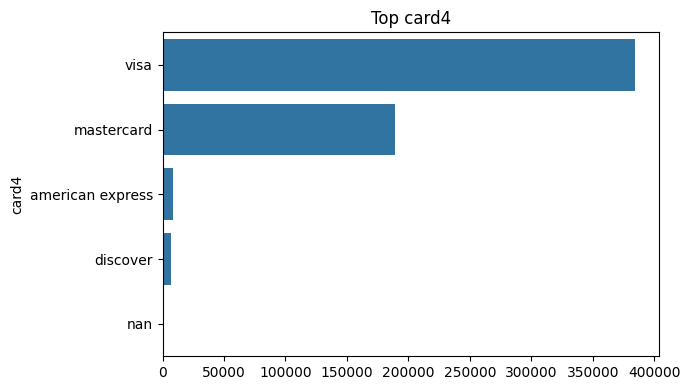

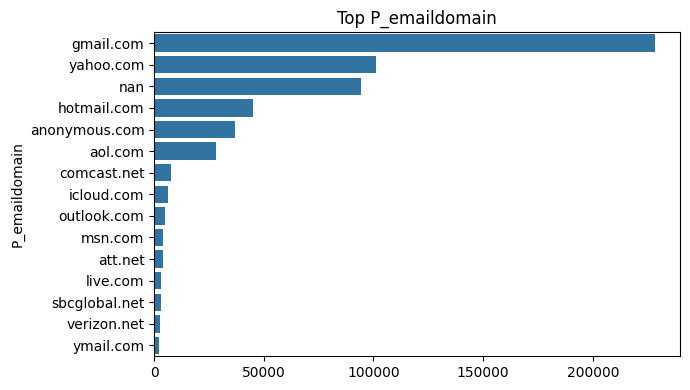

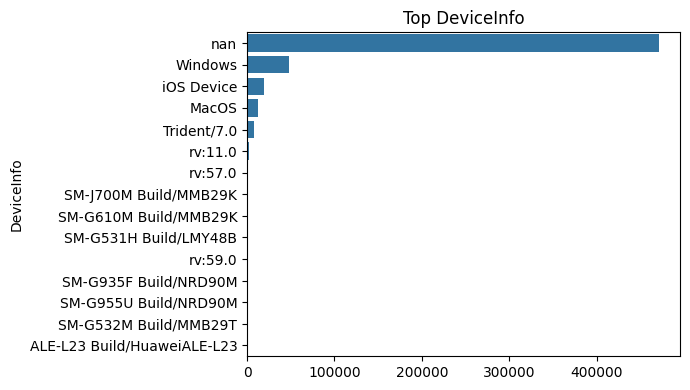

In [3]:
train_tr = pd.read_csv(f"{PATH}/train_transaction.csv")
train_id = pd.read_csv(f"{PATH}/train_identity.csv")
train = train_tr.merge(train_id, on="TransactionID", how="left")
del train_tr, train_id
gc.collect()

train = reduce_mem_usage(train)
print("OK — Rows, Cols:", train.shape)
print(train.dtypes.value_counts())

print("Fraud rate:", train["isFraud"].mean())
train["isFraud"].value_counts(normalize=True).plot.bar(title="Class balance")
plt.tight_layout()
plt.savefig("eda_class_balance.png", dpi=150)
plt.show()

nulls = train.isna().mean().sort_values(ascending=False).head(20)
plt.figure(figsize=(6, 5))
sns.barplot(x=nulls.values, y=nulls.index)
plt.title("Top-20 missingness")
plt.xlabel("Fraction missing")
plt.tight_layout()
plt.savefig("eda_missingness.png", dpi=150)
plt.show()

if "TransactionAmt" in train.columns:
    sns.histplot(train["TransactionAmt"].dropna(), bins=100, log_scale=(False, True))
    plt.title("TransactionAmt (y-log)")
    plt.tight_layout()
    plt.savefig("eda_transaction_amt.png", dpi=150)
    plt.show()

for col in ["ProductCD", "card4", "P_emaildomain", "DeviceInfo"]:
    if col in train.columns:
        vc = train[col].astype(str).value_counts().head(15)
        plt.figure(figsize=(7, 4))
        sns.barplot(x=vc.values, y=vc.index)
        plt.title(f"Top {col}")
        plt.tight_layout()
        plt.savefig(f"eda_top_{col}.png", dpi=150)
        plt.show()

In [4]:
target = "isFraud"
drop_cols = ["TransactionID", "TransactionDT", target]
all_cols = [c for c in train.columns if c not in drop_cols]

cat_cols = [
    c for c in [
        "ProductCD", "card1", "card2", "card3", "card4", "card5", "card6",
        "addr1", "addr2", "P_emaildomain", "R_emaildomain",
        "M1", "M2", "M3", "M4", "M5", "M6", "M7", "M8", "M9",
        "DeviceType", "DeviceInfo",
        "id_12", "id_13", "id_14", "id_15", "id_16", "id_17", "id_18", "id_19", "id_20",
        "id_21", "id_22", "id_23", "id_24", "id_25", "id_26", "id_27", "id_28", "id_29",
        "id_30", "id_31", "id_32", "id_33", "id_34", "id_35", "id_36", "id_37", "id_38",
    ] if c in train.columns
]
num_cols = [c for c in all_cols if c not in cat_cols]
print("STEP 4 OK —", len(cat_cols), "categoricals;", len(num_cols), "numerics")

q80 = train["TransactionDT"].quantile(0.8)
q90 = train["TransactionDT"].quantile(0.9)
df_train = train[train["TransactionDT"] < q80].copy()
df_valid = train[(train["TransactionDT"] >= q80) & (train["TransactionDT"] < q90)].copy()
df_test = train[train["TransactionDT"] >= q90].copy()
y_train = df_train[target].astype(int).values
y_valid = df_valid[target].astype(int).values
y_test = df_test[target].astype(int).values
print("Splits:", df_train.shape, df_valid.shape, df_test.shape)


STEP 4 OK — 49 categoricals; 382 numerics
Splits: (472432, 434) (59054, 434) (59054, 434)


In [5]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, StandardScaler

use_standard_scaler = False
num_imputer = SimpleImputer(strategy="median")
scaler = StandardScaler() if use_standard_scaler else RobustScaler()

Xtr_num = num_imputer.fit_transform(df_train[num_cols])
Xtr_num = scaler.fit_transform(Xtr_num)
Xva_num = scaler.transform(num_imputer.transform(df_valid[num_cols]))
Xte_num = scaler.transform(num_imputer.transform(df_test[num_cols]))

train_medians = pd.Series(num_imputer.statistics_, index=num_cols)
train_medians.to_csv("train_numeric_medians.csv", index=True)
print(" — Saved train_numeric_medians.csv")


def fit_category_map(series, min_freq=50):
    vc = series.astype(str).value_counts()
    kept = sorted(vc[vc >= min_freq].index)
    return {v: i + 1 for i, v in enumerate(kept)}


cat_maps = {c: fit_category_map(df_train[c], min_freq=50) for c in cat_cols}


def cat_to_idx(df, cat_cols, cat_maps):
    arrs = []
    for c in cat_cols:
        m = cat_maps[c]
        arrs.append(df[c].astype(str).map(m).fillna(0).astype(int).values)
    return arrs, [len(cat_maps[c]) + 1 for c in cat_cols]


Xtr_cat_list, cat_vocab_sizes = cat_to_idx(df_train, cat_cols, cat_maps)
Xva_cat_list, _ = cat_to_idx(df_valid, cat_cols, cat_maps)
Xte_cat_list, _ = cat_to_idx(df_test, cat_cols, cat_maps)

 — Saved train_numeric_medians.csv


In [6]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    confusion_matrix,
    brier_score_loss,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.calibration import calibration_curve

torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("STEP 6 — device:", device)


def make_tensor(num_np, cat_lists):
    x_num = torch.tensor(num_np, dtype=torch.float32)
    x_cats = [torch.tensor(c, dtype=torch.long) for c in cat_lists]
    return x_num, x_cats


Xtr_num_t, Xtr_cats_t = make_tensor(Xtr_num, Xtr_cat_list)
Xva_num_t, Xva_cats_t = make_tensor(Xva_num, Xva_cat_list)
Xte_num_t, Xte_cats_t = make_tensor(Xte_num, Xte_cat_list)

ytr_t = torch.tensor(y_train, dtype=torch.float32)
yva_t = torch.tensor(y_valid, dtype=torch.float32)
yte_t = torch.tensor(y_test, dtype=torch.float32)


class MLPEmb(nn.Module):
    def __init__(
        self,
        num_in_dim,
        cat_vocab_sizes,
        emb_dim_rule=lambda v: min(50, int(round(v ** 0.25)) + 1),
        hidden=None,
        dropout=0.3,
    ):
        super().__init__()
        if hidden is None:
            hidden = [512, 256, 128]
        self.emb_layers = nn.ModuleList(
            [nn.Embedding(v, emb_dim_rule(v), padding_idx=0) for v in cat_vocab_sizes]
        )
        emb_total = sum(e.embedding_dim for e in self.emb_layers)
        in_dim = num_in_dim + emb_total
        layers, d = [], in_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.BatchNorm1d(h), nn.SiLU(), nn.Dropout(dropout)]
            d = h
        layers += [nn.Linear(d, 1)]
        self.mlp = nn.Sequential(*layers)

    def forward(self, x_num, x_cats):
        embs = [emb(x) for emb, x in zip(self.emb_layers, x_cats)]
        x = torch.cat([x_num] + embs, dim=1)
        return self.mlp(x).squeeze(1)


class TabDS(Dataset):
    def __init__(self, xnum, xcats, y):
        self.xnum = xnum
        self.xcats = xcats
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return (self.xnum[i], [c[i] for c in self.xcats], self.y[i])


def collate(batch):
    xn = torch.stack([b[0] for b in batch], 0)
    xcs = list(zip(*[b[1] for b in batch]))
    xcs = [torch.stack(x, 0) for x in xcs]
    y = torch.stack([b[2] for b in batch], 0)
    return xn, xcs, y


train_ds = TabDS(Xtr_num_t, Xtr_cats_t, ytr_t)
valid_ds = TabDS(Xva_num_t, Xva_cats_t, yva_t)

train_loader = DataLoader(train_ds, batch_size=2048, shuffle=True, drop_last=True, collate_fn=collate)
valid_loader = DataLoader(valid_ds, batch_size=4096, shuffle=False, collate_fn=collate)

print("STEP  OK — DataLoaders ready")


def current_lr(optimizer):
    return optimizer.param_groups[0]["lr"]


def train_one_model(model, train_loader, valid_loader, device, max_epochs=15, patience=6, lr=3e-4, wd=1e-5):
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=2)
    best_ap, best_state, wait = -1.0, None, 0

    for epoch in range(max_epochs):
        model.train()
        for xn, xcs, y in train_loader:
            xn, y = xn.to(device), y.to(device)
            xcs = [xc.to(device) for xc in xcs]
            opt.zero_grad()
            logits = model(xn, xcs)
            loss = nn.functional.binary_cross_entropy_with_logits(logits, y)
            loss.backward()
            opt.step()

        model.eval()
        preds, targs = [], []
        with torch.no_grad():
            for xn, xcs, y in valid_loader:
                xn = xn.to(device)
                xcs = [xc.to(device) for xc in xcs]
                p = torch.sigmoid(model(xn, xcs)).cpu().numpy()
                preds.append(p)
                targs.append(y.numpy())
        preds = np.concatenate(preds)
        targs = np.concatenate(targs)
        ap = average_precision_score(targs, preds)
        sched.step(ap)
        print(f"  epoch {epoch:02d}  val AUPRC={ap:.5f}  lr={current_lr(opt):.2e}")

        if ap > best_ap + 1e-4:
            best_ap = ap
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best_ap


def predict_probs(model, Xnum_t, Xcats_t, y_true, batch_size=4096):
    ds = TabDS(Xnum_t, Xcats_t, torch.tensor(y_true, dtype=torch.float32))
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, collate_fn=collate)
    model.eval()
    out = []
    with torch.no_grad():
        for xn, xcs, _ in dl:
            xn = xn.to(device)
            xcs = [xc.to(device) for xc in xcs]
            out.append(torch.sigmoid(model(xn, xcs)).cpu().numpy())
    return np.concatenate(out)


def best_f1_threshold(y_true, y_score):
    prec, rec, thr = precision_recall_curve(y_true, y_score)
    best_f1, best_t = -1.0, 0.5
    for i in range(len(thr)):
        p, r = prec[i + 1], rec[i + 1]
        f1 = 2 * p * r / (p + r + 1e-9)
        if f1 > best_f1:
            best_f1, best_t = f1, float(thr[i])
    return best_t, best_f1


def recall_at_k(y_true, y_score, k):
    idx = np.argsort(-y_score)[:k]
    return float(y_true[idx].sum() / (y_true.sum() + 1e-9))


STEP 6 — device: cuda
STEP  OK — DataLoaders ready


In [7]:
configs = [
    {"name": "MLPEmb_base", "hidden": [512, 256, 128], "dropout": 0.30},
    {"name": "MLPEmb_small", "hidden": [256, 128], "dropout": 0.20},
    {"name": "MLPEmb_deep", "hidden": [1024, 512, 256, 128], "dropout": 0.40},
]

results = []
trained_models = {}
val_probs_by_name = {}
test_probs_by_name = {}

for cfg in configs:
    print(f"\n=== STEP  — Training {cfg['name']} ===")
    torch.manual_seed(SEED)
    model = MLPEmb(
        num_in_dim=Xtr_num.shape[1],
        cat_vocab_sizes=cat_vocab_sizes,
        hidden=cfg["hidden"],
        dropout=cfg["dropout"],
    ).to(device)
    model, best_ap = train_one_model(
        model, train_loader, valid_loader, device=device, max_epochs=15, patience=6
    )
    trained_models[cfg["name"]] = model

    yva_pred = predict_probs(model, Xva_num_t, Xva_cats_t, y_valid)
    yte_pred = predict_probs(model, Xte_num_t, Xte_cats_t, y_test)
    val_probs_by_name[cfg["name"]] = yva_pred
    test_probs_by_name[cfg["name"]] = yte_pred

    t_star, _ = best_f1_threshold(y_valid, yva_pred)
    yva_hat = (yva_pred >= t_star).astype(int)
    yte_hat = (yte_pred >= t_star).astype(int)

    row = {
        "model": cfg["name"],
        "hidden_layers": str(cfg["hidden"]),
        "dropout": cfg["dropout"],
        "val_AUPRC": average_precision_score(y_valid, yva_pred),
        "val_AUROC": roc_auc_score(y_valid, yva_pred),
        "val_F1_at_tstar": f1_score(y_valid, yva_hat),
        "val_Prec_at_tstar": precision_score(y_valid, yva_hat, zero_division=0),
        "val_Rec_at_tstar": recall_score(y_valid, yva_hat, zero_division=0),
        "test_AUPRC": average_precision_score(y_test, yte_pred),
        "test_AUROC": roc_auc_score(y_test, yte_pred),
        "test_F1_at_tstar": f1_score(y_test, yte_hat),
        "test_Prec_at_tstar": precision_score(y_test, yte_hat, zero_division=0),
        "test_Rec_at_tstar": recall_score(y_test, yte_hat, zero_division=0),
        "t_star_from_valid": t_star,
        "best_val_AUPRC_during_train": best_ap,
    }
    for k in [100, 500, 1000]:
        row[f"val_RecallAt{k}"] = recall_at_k(y_valid, yva_pred, k)
        row[f"test_RecallAt{k}"] = recall_at_k(y_test, yte_pred, k)
    results.append(row)

results_df = pd.DataFrame(results).sort_values("val_AUPRC", ascending=False)
results_df.to_csv("ann_model_comparison.csv", index=False)
print("\n Comparison (sorted by val AUPRC):")
print(results_df.to_string(index=False))
print("Saved ann_model_comparison.csv")


=== STEP  — Training MLPEmb_base ===
  epoch 00  val AUPRC=0.10023  lr=3.00e-04
  epoch 01  val AUPRC=0.20930  lr=3.00e-04
  epoch 02  val AUPRC=0.23464  lr=3.00e-04
  epoch 03  val AUPRC=0.25525  lr=3.00e-04
  epoch 04  val AUPRC=0.28311  lr=3.00e-04
  epoch 05  val AUPRC=0.27714  lr=3.00e-04
  epoch 06  val AUPRC=0.28408  lr=3.00e-04
  epoch 07  val AUPRC=0.31351  lr=3.00e-04
  epoch 08  val AUPRC=0.31788  lr=3.00e-04
  epoch 09  val AUPRC=0.31628  lr=3.00e-04
  epoch 10  val AUPRC=0.33825  lr=3.00e-04
  epoch 11  val AUPRC=0.33430  lr=3.00e-04
  epoch 12  val AUPRC=0.35001  lr=3.00e-04
  epoch 13  val AUPRC=0.31167  lr=3.00e-04
  epoch 14  val AUPRC=0.35291  lr=3.00e-04

=== STEP  — Training MLPEmb_small ===
  epoch 00  val AUPRC=0.10021  lr=3.00e-04
  epoch 01  val AUPRC=0.20694  lr=3.00e-04
  epoch 02  val AUPRC=0.21555  lr=3.00e-04
  epoch 03  val AUPRC=0.25420  lr=3.00e-04
  epoch 04  val AUPRC=0.25975  lr=3.00e-04
  epoch 05  val AUPRC=0.29543  lr=3.00e-04
  epoch 06  val AUPR

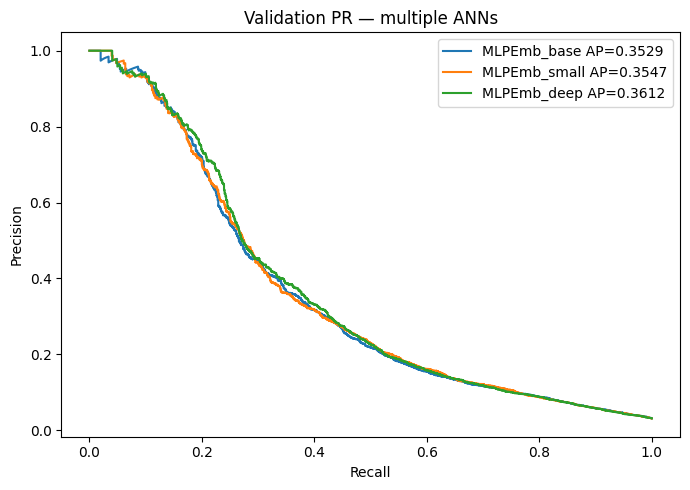

STEP 8 OK — Saved compare_pr_validation.png


In [8]:
plt.figure(figsize=(7, 5))
for name, yva_pred in val_probs_by_name.items():
    prec, rec, _ = precision_recall_curve(y_valid, yva_pred)
    ap = average_precision_score(y_valid, yva_pred)
    plt.plot(rec, prec, label=f"{name} AP={ap:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Validation PR — multiple ANNs")
plt.legend()
plt.tight_layout()
plt.savefig("compare_pr_validation.png", dpi=150)
plt.show()
print("STEP 8 OK — Saved compare_pr_validation.png")


STEP 9 — Best model by val AUPRC: MLPEmb_deep
[VALID] AUPRC=0.36121 AUROC=0.84604  t*=0.1359
[VALID] F1: 0.3723202170963365 Prec: 0.37404580152671757 Rec: 0.37061048082117776


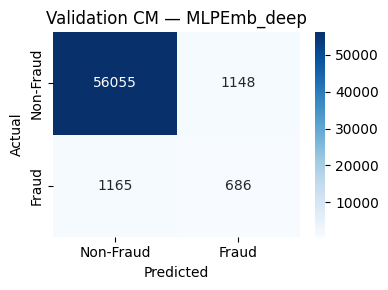

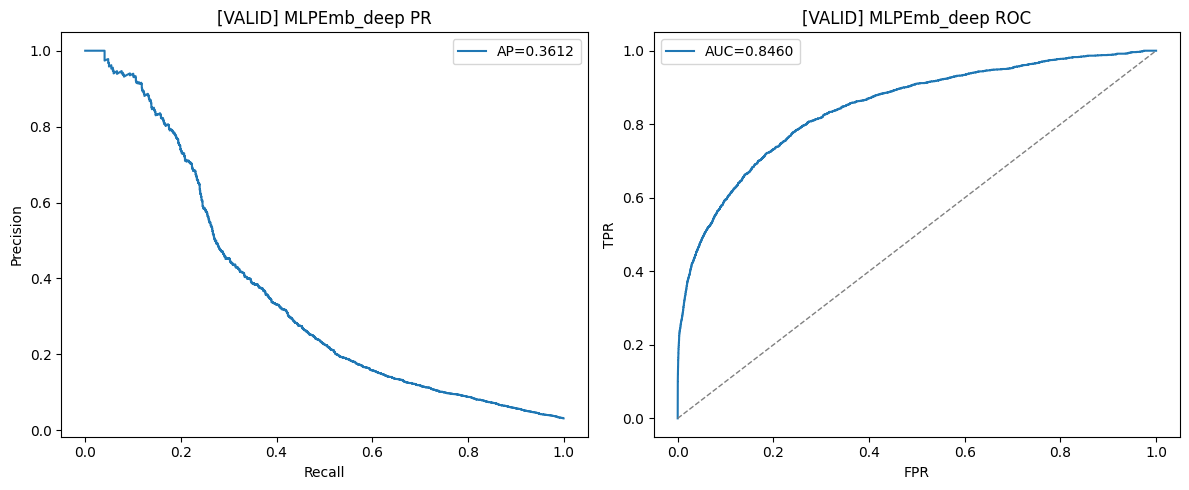

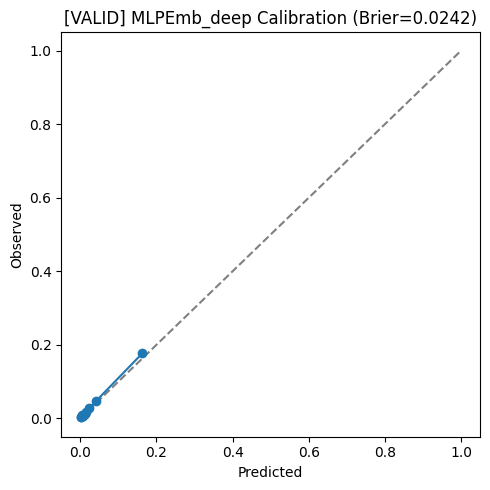

[VALID] Recall@100: 0.0519
[VALID] Recall@500: 0.1999
[VALID] Recall@1000: 0.2712

[TEST]  AUPRC=0.41252 AUROC=0.87187  (t* from valid)
[TEST]  F1: 0.4080071974808817 Prec: 0.406180026869682 Rec: 0.40985088115680074


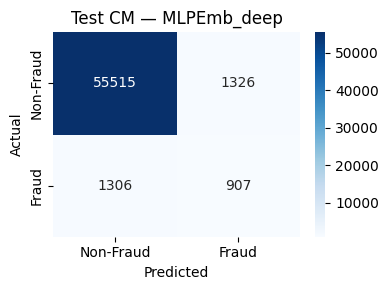

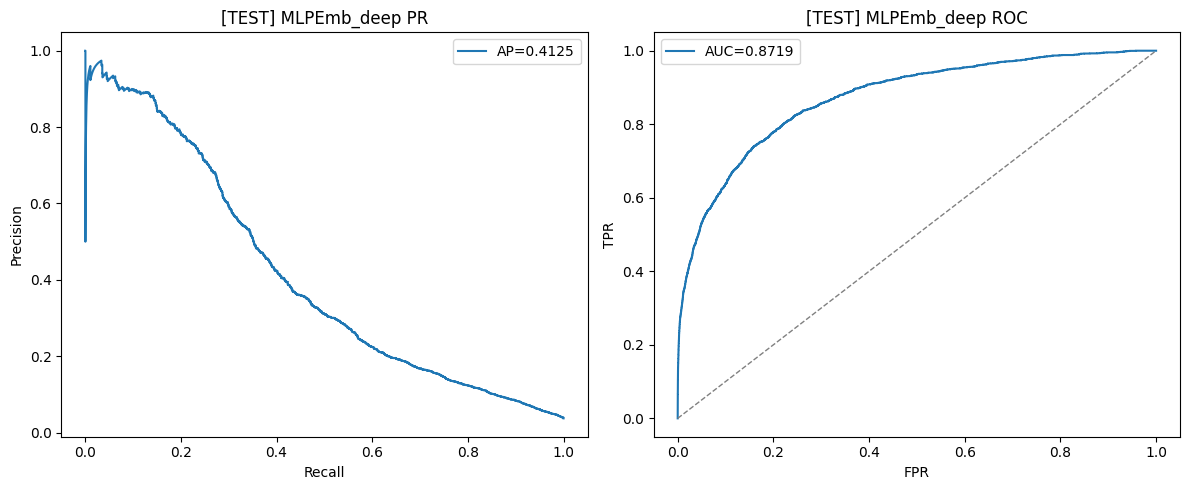

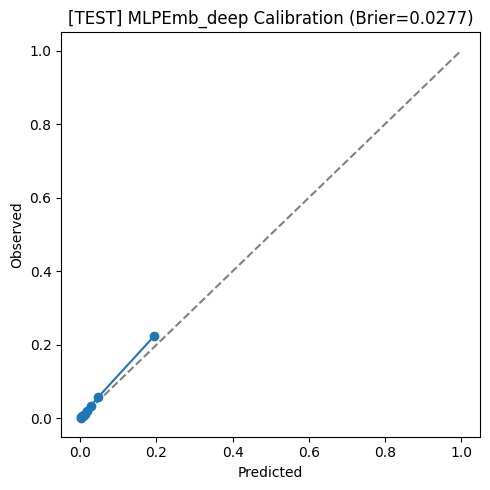

[TEST]  Recall@100: 0.0425
[TEST]  Recall@500: 0.1826
[TEST]  Recall@1000: 0.2856


In [9]:
best_name = results_df.iloc[0]["model"]
print(f"\nSTEP 9 — Best model by val AUPRC: {best_name}")
best_model = trained_models[best_name]
yva_pred = val_probs_by_name[best_name]
yte_pred = test_probs_by_name[best_name]

t_star, _ = best_f1_threshold(y_valid, yva_pred)
print(f"[VALID] AUPRC={average_precision_score(y_valid, yva_pred):.5f} "
      f"AUROC={roc_auc_score(y_valid, yva_pred):.5f}  t*={t_star:.4f}")

yva_hat = (yva_pred >= t_star).astype(int)
print(
    "[VALID] F1:", f1_score(y_valid, yva_hat),
    "Prec:", precision_score(y_valid, yva_hat, zero_division=0),
    "Rec:", recall_score(y_valid, yva_hat, zero_division=0),
)


def plot_pr_roc(y_true, y_score, title_prefix="", save_prefix=""):
    prec, rec, _ = precision_recall_curve(y_true, y_score)
    fpr, tpr, _ = roc_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)
    auc = roc_auc_score(y_true, y_score)
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    ax[0].plot(rec, prec, label=f"AP={ap:.4f}")
    ax[0].set_xlabel("Recall")
    ax[0].set_ylabel("Precision")
    ax[0].set_title(f"{title_prefix} PR")
    ax[0].legend()
    ax[1].plot(fpr, tpr, label=f"AUC={auc:.4f}")
    ax[1].plot([0, 1], [0, 1], "--", c="gray", lw=1)
    ax[1].set_xlabel("FPR")
    ax[1].set_ylabel("TPR")
    ax[1].set_title(f"{title_prefix} ROC")
    ax[1].legend()
    plt.tight_layout()
    if save_prefix:
        plt.savefig(f"{save_prefix}_pr_roc.png", dpi=150)
    plt.show()


def plot_calibration(y_true, y_score, n_bins=10, title_prefix="", save_prefix=""):
    prob_true, prob_pred = calibration_curve(y_true, y_score, n_bins=n_bins, strategy="quantile")
    bs = brier_score_loss(y_true, y_score)
    plt.figure(figsize=(5, 5))
    plt.plot([0, 1], [0, 1], "--", c="gray")
    plt.plot(prob_pred, prob_true, marker="o")
    plt.xlabel("Predicted")
    plt.ylabel("Observed")
    plt.title(f"{title_prefix} Calibration (Brier={bs:.4f})")
    plt.tight_layout()
    if save_prefix:
        plt.savefig(f"{save_prefix}_calibration.png", dpi=150)
    plt.show()


def plot_cm(y_true, y_pred, title="Confusion matrix", save_path=None):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Non-Fraud", "Fraud"],
        yticklabels=["Non-Fraud", "Fraud"],
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()
    tn, fp, fn, tp = cm.ravel()
    return {"TP": int(tp), "FP": int(fp), "TN": int(tn), "FN": int(fn)}


_ = plot_cm(y_valid, yva_hat, f"Validation CM — {best_name}", save_path="best_valid_cm.png")
plot_pr_roc(y_valid, yva_pred, f"[VALID] {best_name}", save_prefix="best_valid")
plot_calibration(y_valid, yva_pred, title_prefix=f"[VALID] {best_name}", save_prefix="best_valid")

for k in [100, 500, 1000]:
    print(f"[VALID] Recall@{k}: {recall_at_k(y_valid, yva_pred, k):.4f}")

print(
    f"\n[TEST]  AUPRC={average_precision_score(y_test, yte_pred):.5f} "
    f"AUROC={roc_auc_score(y_test, yte_pred):.5f}  (t* from valid)"
)
yte_hat = (yte_pred >= t_star).astype(int)
print(
    "[TEST]  F1:", f1_score(y_test, yte_hat),
    "Prec:", precision_score(y_test, yte_hat, zero_division=0),
    "Rec:", recall_score(y_test, yte_hat, zero_division=0),
)
_ = plot_cm(y_test, yte_hat, f"Test CM — {best_name}", save_path="best_test_cm.png")
plot_pr_roc(y_test, yte_pred, f"[TEST] {best_name}", save_prefix="best_test")
plot_calibration(y_test, yte_pred, title_prefix=f"[TEST] {best_name}", save_prefix="best_test")

for k in [100, 500, 1000]:
    print(f"[TEST]  Recall@{k}: {recall_at_k(y_test, yte_pred, k):.4f}")
